In [105]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_openrouter import ChatOpenRouter
from dotenv import load_dotenv
import os

load_dotenv()

API_KEY = os.getenv("GEMINI_API_KEY")
llm = ChatGoogleGenerativeAI(api_key=API_KEY, model="gemini-3.1-flash-lite")
# llm=ChatOpenRouter(api_key=os.getenv("OPENROUTER_API_KEY"),model="")


In [106]:
### Orchestrator Flow ( Boshqaruvchi graph. Yani bitta katta topshiriqni kichik topshiriqlarga bolib bajarish uchun qollaniladi.)
from pydantic import BaseModel, Field
from typing import List, TypedDict


class llm_schema(BaseModel):
    tasks: List[str] = Field(..., description="Berilgan mavzu bo'yicha vazifalarga ajratib oling!")


class graph_schema(TypedDict):
    user_query: str
    tasks: List[str]
    results: List[str]
    summary: str

In [107]:
# Tasklarga bolib olamiz.
def separate_tasks(state: graph_schema) -> graph_schema:
    user_query = state["user_query"]
    prompt = ChatPromptTemplate.from_messages([
        ('system',
         "Siz aqlli dastur yordamchisiz. Sizga bitta kattaroq mavzu beriladi. Siz shu mavzuni kichik bo'laklarga bo'linib to'liq o'rganib chiqishni taminlashingiz kerak. Yani uni kichik bo'laklarga bo'lishingiz kerak boaldi."),
        ('human',
         "Sizga quydagicha {user_query} mavzu berildi. Shuni to'liq o'rganish uchun bo'laklarga task larga ajrating.")
    ])
    llm_with_structure = llm.with_structured_output(llm_schema)
    chain = prompt | llm_with_structure
    response = chain.invoke({"user_query": user_query})
    state['tasks'] = response.tasks
    return state


In [108]:
# Endi bo'lib olingan mavzular haqida malumotlar topishimiz kerak bo'ladi !
def execute_ai(query: str):
    prompt = ChatPromptTemplate.from_template("Ushbu {query} mavzu haqida to'liq qilib malumot bering")
    chain = prompt | llm
    response = chain.invoke({"query": query})
    return response.content[0]['text']

In [109]:
# Endi esa bo'lib olingan mavzularni ishga tushiramiz va malumotlarini jamlaymiz
from concurrent.futures import ThreadPoolExecutor


def return_results(state: graph_schema):
    tasks = state['tasks']
    natijalar = []

    with ThreadPoolExecutor(len(tasks)) as executor:
        for natija in executor.map(execute_ai, tasks):
            natijalar.append(natija)
    state['results'] = natijalar
    return state


In [110]:
# Xulosa chiqaradi ai bu malumotlar asosida !
from langchain_core.output_parsers import StrOutputParser

parser = StrOutputParser()


def get_summary(state: graph_schema) -> graph_schema:
    results = state['results']
    tasks = state['tasks']
    formatter = "".join([f"### {t}\n\n {r}" for t, r in zip(tasks, results)])
    prompt = ChatPromptTemplate.from_template(
        "Siz bu malumotlar asosida xulosa chiqaring. MALUMOTLAR : {formatter}")
    chain = prompt | llm | parser
    response = chain.invoke({"formatter": formatter})
    state['summary'] = response
    return state

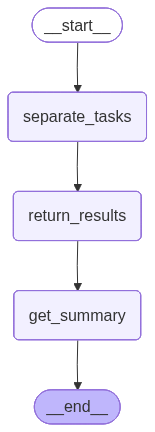

None


In [111]:
from langgraph.graph import START, StateGraph, END

graph = StateGraph(graph_schema)

graph.add_node("separate_tasks", separate_tasks)
graph.add_node("return_results", return_results)
graph.add_node("get_summary", get_summary)

graph.add_edge(START, "separate_tasks")
graph.add_edge('separate_tasks', "return_results")
graph.add_edge('return_results', "get_summary")
graph.add_edge('get_summary', END)

compile_graph = graph.compile()

from IPython.display import display, Image

print(display(Image(compile_graph.get_graph().draw_mermaid_png())))


In [112]:
yakuniy_natija = compile_graph.invoke({
    "user_query": "O'zbekiston mustaqillik yillaridagi o'zgarishlar aholi, davlat qo'mitalari va yer. mol-mulk resurslarida.",
    "tasks": [],
    "results": [],
    'summary': ""
})
yakuniy_natija


{'user_query': "O'zbekiston mustaqillik yillaridagi o'zgarishlar aholi, davlat qo'mitalari va yer. mol-mulk resurslarida.",
 'tasks': ["O'zbekiston demografik rivojlanishi va aholi turmush darajasidagi asosiy o'zgarishlar tahlili",
  "Davlat boshqaruvi tizimi va davlat qo'mitalari faoliyatining isloh qilinishi",
  "Yer resurslaridan foydalanish huquqi va yer munosabatlaridagi qonunchilik o'zgarishlari",
  'Xususiy mulkchilik institutining shakllanishi va mol-mulk huquqini himoya qilish mexanizmlari',
  "Mustaqillik davrida iqtisodiy islohotlarning aholi ijtimoiy himoyasiga ta'siri",
  "Davlat idoralarining raqamlashtirilishi va davlat xizmatlari ko'rsatish samaradorligini tahlil qilish",
  "Yer va ko'chmas mulk bozorining rivojlanishi hamda baholash tizimidagi o'zgarishlar"],
 'results': ['O‘zbekistonning demografik rivojlanishi va aholi turmush darajasidagi o‘zgarishlar oxirgi yillarda mamlakatdagi ijtimoiy-iqtisodiy islohotlarning eng muhim ko‘rsatkichi hisoblanadi. Quyida ushbu mavz